In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/alpha_genome_validation/ctct_suppressing/fold0_alphagenome_GCpoly_results.tsv", sep="\t")

fold0["fold"] = [0 for i in range(len(fold0))]

In [3]:
fold1 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/alpha_genome_validation/ctct_suppressing/fold1_alphagenome_GCpoly_results.tsv", sep="\t")

fold1["fold"] = [1 for i in range(len(fold1))]

In [4]:
fold2 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/alpha_genome_validation/ctct_suppressing/fold2_alphagenome_GCpoly_results.tsv", sep="\t")

fold2["fold"] = [2 for i in range(len(fold2))]

In [5]:
fold3 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/alpha_genome_validation/ctct_suppressing/fold3_alphagenome_GCpoly_results.tsv", sep="\t")

fold3["fold"] = [3 for i in range(len(fold3))]

In [6]:
fold4 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/alpha_genome_validation/ctct_suppressing/fold4_alphagenome_GCpoly_results.tsv", sep="\t")

fold4["fold"] = [4 for i in range(len(fold4))]

In [7]:
fold5 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/alpha_genome_validation/ctct_suppressing/fold5_alphagenome_GCpoly_results.tsv", sep="\t")

fold5["fold"] = [5 for i in range(len(fold5))]

In [8]:
fold6 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/alpha_genome_validation/ctct_suppressing/fold6_alphagenome_GCpoly_results.tsv", sep="\t")

fold6["fold"] = [6 for i in range(len(fold6))]

In [9]:
fold7 = pd.read_csv(f"/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/alpha_genome_validation/ctct_suppressing/fold7_alphagenome_GCpoly_results.tsv", sep="\t")

fold7["fold"] = [7 for i in range(len(fold7))]

In [10]:
df = pd.concat([fold0, fold1, fold2, fold3, fold4, fold5, fold6, fold7], ignore_index=True)

In [12]:
df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'alpha_og_urq',
       'alpha_ed_urq', 'alpha_urq_diff', 'alpha_GCpoly_urq',
       'alpha_urq_GCpoly_diff'],
      dtype='object')

In [15]:
print("boundary, before optimization: ", df["alpha_og_urq"].mean())
print("after suppression: ", df["alpha_ed_urq"].mean())
print("suppression, no G and C homopolymers: ", df["alpha_GCpoly_urq"].mean())

boundary, before optimization:  -0.09233239721837437
after suppression:  -0.04788478214507389
suppression, no G and C homopolymers:  -0.04547920937837437


/tmp/SLURM_2662633/ipykernel_444743/30616954.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Insulation Score (URQ)', data=df_long,


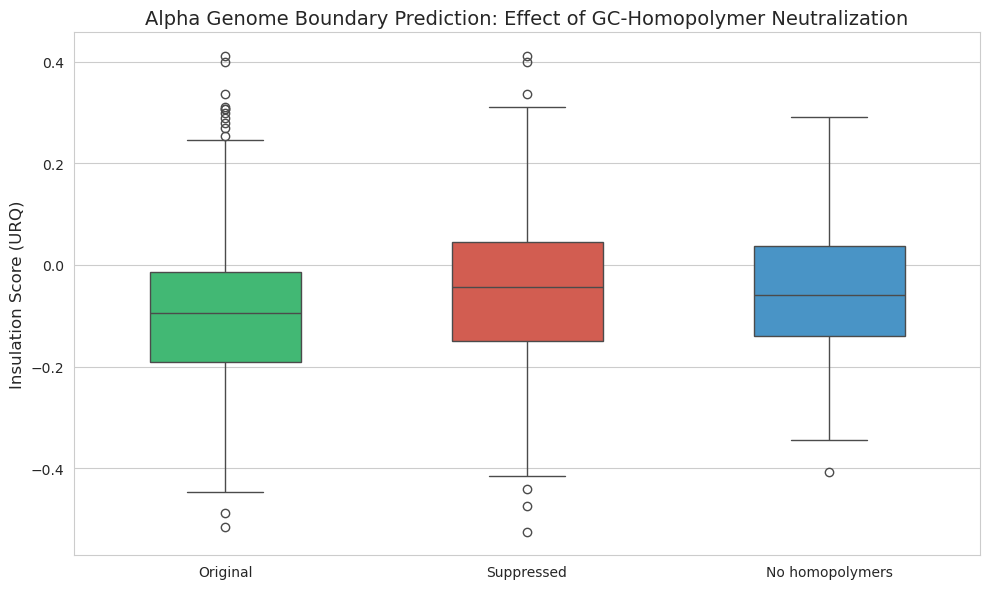

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data for plotting
# We select the three columns of interest and rename them for better labels
plot_df = df[['alpha_og_urq', 'alpha_ed_urq', 'alpha_GCpoly_urq']].copy()
plot_df.columns = ['Original', 'Suppressed', 'No homopolymers']

# 2. Convert to long format for Seaborn
df_long = plot_df.melt(var_name='Condition', value_name='Insulation Score (URQ)')

# 3. Create the plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create boxplot with a swarmplot overlay to see individual points
sns.boxplot(x='Condition', y='Insulation Score (URQ)', data=df_long, 
            palette=['#2ecc71', '#e74c3c', '#3498db'], width=0.5)

# 4. Add labels and horizontal line at 0 for reference
plt.title('Alpha Genome Boundary Prediction: Effect of GC-Homopolymer Neutralization', fontsize=14)
plt.ylabel('Insulation Score (URQ)', fontsize=12)
plt.xlabel('')

# Tight layout and save
plt.tight_layout()
plt.show()